In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('weight-height.csv')
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


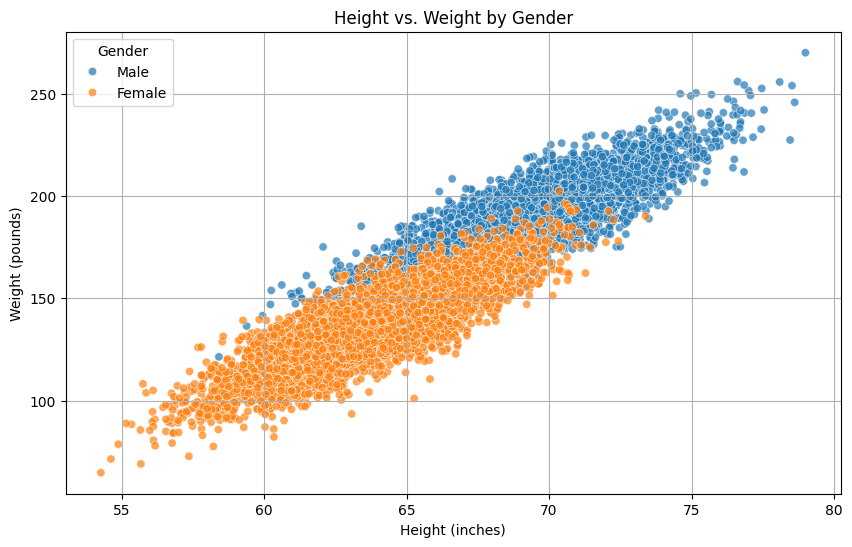

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Gender', alpha=0.7)
plt.title('Height vs. Weight by Gender')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.grid(True)
plt.show()

In [ ]:
# Select the features for clustering
X = df[['Height', 'Weight']]

### Elbow Method to Determine Optimal Number of Clusters (k)

To find the optimal number of clusters for K-means, we'll use the elbow method. This method involves computing the Within-Cluster Sum of Squares (WCSS) for different values of `k` (number of clusters) and plotting the results. The 'elbow' point in the plot, where the rate of decrease in WCSS significantly changes, indicates the optimal `k`.

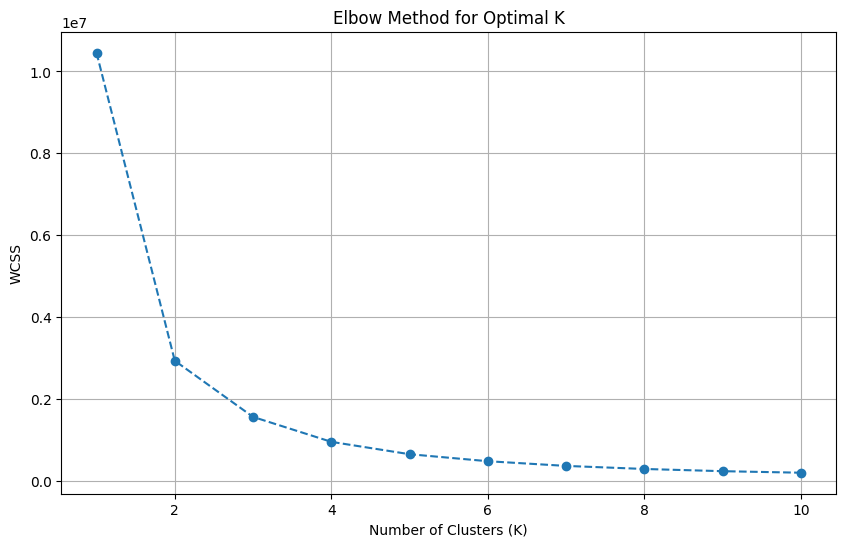

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### Applying K-Means Clustering with Optimal K

Now that we've determined the optimal number of clusters (K=2) using the elbow method, we will apply the K-Means algorithm to our data (`Height` and `Weight`). After clustering, we'll add the cluster labels back to our original DataFrame and visualize the results to see how the data points are grouped.

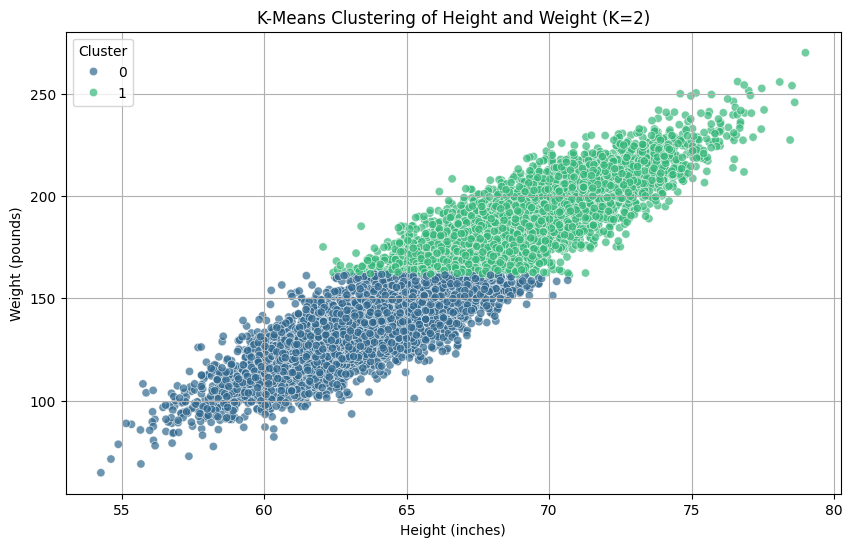

,count
Cluster,
0,5041
1,4959


In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)
df['Cluster'] = y_kmeans

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Cluster', palette='viridis', alpha=0.7)
plt.title('K-Means Clustering of Height and Weight (K=2)')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.grid(True)
plt.show()

# Display the count of observations in each cluster
display(df['Cluster'].value_counts())

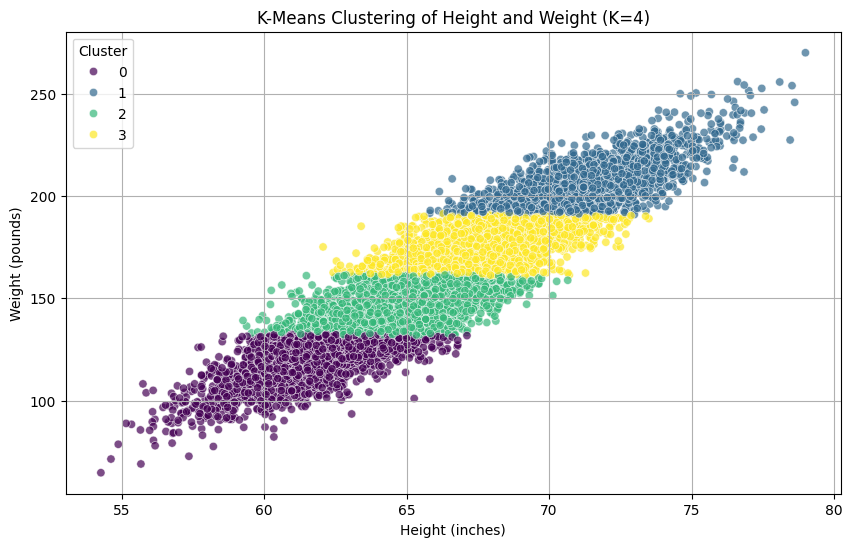

,count
Cluster,
2,2894
3,2874
1,2116
0,2116


In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)
df['Cluster'] = y_kmeans

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Cluster', palette='viridis', alpha=0.7)
plt.title('K-Means Clustering of Height and Weight (K=4)')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.grid(True)
plt.show()

# Display the count of observations in each cluster
display(df['Cluster'].value_counts())